# Multilayer ice flow model

In this tutorial we will build up the multilayer ice flow model step by step.
We start with the single-layer shallow shelf approximation (SSA), extend it
to two layers with the same rheology, and finally introduce a composite
rheology where the basal layer deforms by a different mechanism than the
upper ice column.

The model follows [Jouvet (2015)](https://doi.org/10.1017/jfm.2014.689) and
uses the dual formulation from [icepack2](https://github.com/icepack/icepack2),
where the membrane stress and interlayer shear stress are explicit unknowns
alongside velocity.

We use the ISMIP-HOM Experiment B geometry (Pattyn et al. 2008) as a test
problem: a parallel-sided slab of ice on a sinusoidal bed, periodic in *x*,
with a frozen (no-slip) base.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import firedrake
from firedrake import (
    Constant, Function, inner, sym, grad, avg, jump,
    sin, dx, dS, FacetNormal, derivative,
    NonlinearVariationalProblem, NonlinearVariationalSolver,
)
from icepack2.model.minimization import viscous_power
from icepack2.constants import ice_density as ρ_I, gravity as g, glen_flow_law
from multilayer.model.minimization import basal_stress_power, interlayer_power
from multilayer.model.utilities import (
    create_function_space, split_fields, layer_thicknesses,
)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


### Geometry

The ISMIP-HOM Experiment B domain is a square of side length $L$ with a
surface that slopes at $\alpha = 0.5°$ and a bed with sinusoidal bumps of
amplitude 500 m:

$$z_s = -x \tan\alpha, \qquad z_b = z_s - 1000 + 500\sin(2\pi x / L).$$

The ice thickness $h = z_s - z_b = 1000 - 500\sin(2\pi x / L)$ is periodic
in $x$.  We use a `PeriodicRectangleMesh` firedrake mesh that is periodic in $x$ with side
walls in $y$ and define a continuous Glerkin function space on the mesh.

In [2]:
Lx = 80e3  # 80 km wavelength
nx = 32
alpha = math.radians(0.5)
tan_alpha = math.tan(alpha)

mesh = firedrake.PeriodicRectangleMesh(nx, nx, Lx, Lx, direction="x")
x, y = firedrake.SpatialCoordinate(mesh)

Q = firedrake.FunctionSpace(mesh, "CG", 1)
omega = Constant(2 * np.pi / Lx)
h_total = Function(Q).interpolate(
    Constant(1000.0) - Constant(500.0) * sin(omega * x)
)

### Rheology and solver parameters

We use the ISMIP-HOM parameters: a rate factor of $A = 100$ MPa$^{-3}$
yr$^{-1}$ and Glen's exponent $n = 3$.  The solver uses Newton's method
with a MUMPS direct solve and continuation from linear ($n = 1$) to the
target exponent.

In [3]:
A = Constant(100.0)
n = Constant(glen_flow_law)

sparams = {
    "snes_type": "newtonls",
    "snes_max_it": 200,
    "snes_linesearch_type": "bt",
    "snes_divergence_tolerance": -1,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

def solve_with_continuation(solver, n_const, target_n, num_steps=5):
    """Ramp the Glen exponent from 1 to target_n."""
    for exponent in np.linspace(1.0, target_n, num_steps):
        n_const.assign(exponent)
        solver.solve()

## Part 1: Single-layer model (SSA)

The single-layer model ($L = 1$) is equivalent to the shallow shelf
approximation.  The multilayer function space for one layer has three
subspaces: velocity $u$, membrane stress $M$, and basal stress $S^0$.

On the frozen base all motion comes from internal deformation — the SSA
treats the entire ice column as a single plug, so the basal stress law
determines how much the ice can slide relative to the bed (which is zero
for no-slip).  We expect the SSA to overpredict velocities because it
has no vertical shear.

In [4]:
num_layers = 1
h_layers = layer_thicknesses(h_total, num_layers)

Z = create_function_space(mesh, num_layers)
z = Function(Z)
fields = split_fields(firedrake.split(z), num_layers)

ν = FacetNormal(mesh)
s_zero = Function(Q).assign(0.0)

# Build the action functional
Lagrangian = Constant(0) * dx(mesh)

fl = fields[0]
u_l, M_l, S_below = fl["velocity"], fl["membrane_stress"], fl["interlayer_stress"]
h_l = h_layers[0]

# Viscous power (from icepack2)
Lagrangian += viscous_power(
    membrane_stress=M_l, thickness=h_l,
    flow_law_coefficient=A, flow_law_exponent=n,
)

# Momentum balance: membrane stress + driving stress + basal traction
ε_u = sym(grad(u_l))
Lagrangian += -h_l * inner(M_l, ε_u) * dx
Lagrangian += -inner(S_below, u_l) * dx
Lagrangian += ρ_I * g * h_l * Constant(tan_alpha) * u_l[0] * dx

# Basal stress power (frozen base)
Lagrangian += basal_stress_power(
    basal_stress=S_below, thickness=h_l,
    flow_law_coefficient=A, flow_law_exponent=n,
)

In [5]:
F = derivative(Lagrangian, z)
bcs = [firedrake.DirichletBC(Z.sub(0).sub(1), 0, (1, 2))]

problem = NonlinearVariationalProblem(
    F, z, bcs, form_compiler_parameters={"quadrature_degree": 8}
)
solver = NonlinearVariationalSolver(problem, solver_parameters=sparams)
solve_with_continuation(solver, n, glen_flow_law)

u_ssa = z.subfunctions[0]

## Part 2: Two-layer model with uniform rheology

We now split the ice column into two equal layers.  Both layers have the
same Glen's law ($n = 3$, $A = 100$).  The velocity is now piecewise
constant in the vertical: each layer has its own horizontal velocity.
The new physics represented by the **interlayer stress** $S^1$ at the interface
between the two layers.  Its constitutive law has the same structure as
the basal stress law:

$$A \lvert S^1 \rvert^{n-1} S^1 = \frac{u^2 - u^1}{h^1 + h^2}$$

The interlayer stress couples the layers through the normalised velocity
jump.  With two layers the model begins to capture vertical shear and
the surface velocity should decrease relative to the SSA.

In [6]:
num_layers = 2
h_layers_2 = layer_thicknesses(h_total, num_layers)

n2 = Constant(glen_flow_law)

Z2 = create_function_space(mesh, num_layers)
z2 = Function(Z2)
fields2 = split_fields(firedrake.split(z2), num_layers)

Lag2 = Constant(0) * dx(mesh)

for l in range(num_layers):
    h_l = h_layers_2[l]
    fl = fields2[l]
    u_l, M_l = fl["velocity"], fl["membrane_stress"]
    S_below = fl["interlayer_stress"]
    S_above = fields2[l + 1]["interlayer_stress"] if l < num_layers - 1 else None

    Lag2 += viscous_power(
        membrane_stress=M_l, thickness=h_l,
        flow_law_coefficient=A, flow_law_exponent=n2,
    )

    ε_u = sym(grad(u_l))
    Lag2 += -h_l * inner(M_l, ε_u) * dx
    Lag2 += -inner(S_below, u_l) * dx
    if S_above is not None:
        Lag2 += inner(S_above, u_l) * dx
    Lag2 += ρ_I * g * h_l * Constant(tan_alpha) * u_l[0] * dx

# Basal stress power (frozen base)
Lag2 += basal_stress_power(
    basal_stress=fields2[0]["interlayer_stress"],
    thickness=h_layers_2[0],
    flow_law_coefficient=A, flow_law_exponent=n2,
)

# Interlayer stress power
Lag2 += interlayer_power(
    interlayer_stress=fields2[1]["interlayer_stress"],
    thickness_above=h_layers_2[1], thickness_below=h_layers_2[0],
    flow_law_coefficient=A, flow_law_exponent=n2,
)

In [7]:
F2 = derivative(Lag2, z2)
bcs2 = [
    firedrake.DirichletBC(Z2.sub(0).sub(1), 0, (1, 2)),
    firedrake.DirichletBC(Z2.sub(3).sub(1), 0, (1, 2)),
]

problem2 = NonlinearVariationalProblem(
    F2, z2, bcs2, form_compiler_parameters={"quadrature_degree": 8}
)
solver2 = NonlinearVariationalSolver(problem2, solver_parameters=sparams)
solve_with_continuation(solver2, n2, glen_flow_law)

u_bottom = z2.subfunctions[0]
u_top = z2.subfunctions[3]

## Part 3: Composite rheology

Ice near the bed is warm and deforms primarily by **dislocation creep**
($n = 4$), while the colder upper ice deforms by **grain boundary
sliding** ($n = 1.8$).  The effective $n \approx 3$ of Glen's law is
an average of these two mechanisms (Goldsby & Kohlstedt 2001, Behn et
al. 2021).

To maintain the same strain rate at a reference stress
$\tau_{\mathrm{ref}} = 0.1$ MPa, the rate factors must be adjusted:

$$A_{\mathrm{new}} = A_{\mathrm{ref}} \cdot
  \tau_{\mathrm{ref}}^{\,n_{\mathrm{ref}} - n_{\mathrm{new}}}$$

| Layer | Mechanism | $n$ | $A$ (MPa$^{-n}$ yr$^{-1}$) |
|-------|-----------|-----|----------------------------|
| Bottom (15%) | Dislocation creep | 4 | 1000 |
| Top (85%) | Grain boundary sliding | 1.8 | 6.3 |

We use a thin basal layer (15% of the column) to concentrate the
vertical shear where it physically occurs.

In [8]:
fractions = [0.15, 0.85]
n_bot_target, n_top_target = 4.0, 1.8
A_bot_target, A_top_target = 1000.0, 6.3

h_layers_c = layer_thicknesses(h_total, 2, fractions=fractions)

n_bot = Constant(glen_flow_law)
n_top = Constant(glen_flow_law)
A_bot = Constant(100.0)
A_top = Constant(100.0)

Zc = create_function_space(mesh, 2)
zc = Function(Zc)
fc = split_fields(firedrake.split(zc), 2)

Lagc = Constant(0) * dx(mesh)

for l, (h_l, n_l, A_l) in enumerate(
    zip(h_layers_c, [n_bot, n_top], [A_bot, A_top])
):
    fl = fc[l]
    u_l, M_l = fl["velocity"], fl["membrane_stress"]
    S_below = fl["interlayer_stress"]
    S_above = fc[l + 1]["interlayer_stress"] if l < 1 else None

    Lagc += viscous_power(
        membrane_stress=M_l, thickness=h_l,
        flow_law_coefficient=A_l, flow_law_exponent=n_l,
    )
    ε_u = sym(grad(u_l))
    Lagc += -h_l * inner(M_l, ε_u) * dx
    Lagc += -inner(S_below, u_l) * dx
    if S_above is not None:
        Lagc += inner(S_above, u_l) * dx
    Lagc += ρ_I * g * h_l * Constant(tan_alpha) * u_l[0] * dx

Lagc += basal_stress_power(
    basal_stress=fc[0]["interlayer_stress"],
    thickness=h_layers_c[0],
    flow_law_coefficient=A_bot, flow_law_exponent=n_bot,
)
Lagc += interlayer_power(
    interlayer_stress=fc[1]["interlayer_stress"],
    thickness_above=h_layers_c[1], thickness_below=h_layers_c[0],
    flow_law_coefficient=A_bot, flow_law_exponent=n_bot,
)

In [9]:
Fc = derivative(Lagc, zc)
bcs_c = [
    firedrake.DirichletBC(Zc.sub(0).sub(1), 0, (1, 2)),
    firedrake.DirichletBC(Zc.sub(3).sub(1), 0, (1, 2)),
]

problem_c = NonlinearVariationalProblem(
    Fc, zc, bcs_c, form_compiler_parameters={"quadrature_degree": 8}
)
solver_c = NonlinearVariationalSolver(problem_c, solver_parameters=sparams)

# Continuation: ramp n and A from linear/uniform to composite (log-space for A)
A_start = 100.0
for λ in np.linspace(0.0, 1.0, 10):
    n_bot.assign((1 - λ) + λ * n_bot_target)
    n_top.assign((1 - λ) + λ * n_top_target)
    A_bot.assign(np.exp((1 - λ) * np.log(A_start) + λ * np.log(A_bot_target)))
    A_top.assign(np.exp((1 - λ) * np.log(A_start) + λ * np.log(A_top_target)))
    solver_c.solve()

u_comp_bot = zc.subfunctions[0]
u_comp_top = zc.subfunctions[3]

## Comparison

We extract the surface velocity along the centreline $y = L/2$ and
compare the three configurations.

In [10]:
n_sample = 101
x_hat = np.linspace(0, 1, n_sample)
y_mid = Lx / 2

def extract_profile(u_func):
    return np.array([u_func.at([xi * Lx, y_mid])[0] for xi in x_hat])

profile_ssa = extract_profile(u_ssa)
profile_top = extract_profile(u_top)
profile_bot = extract_profile(u_bottom)
profile_comp_top = extract_profile(u_comp_top)
profile_comp_bot = extract_profile(u_comp_bot)

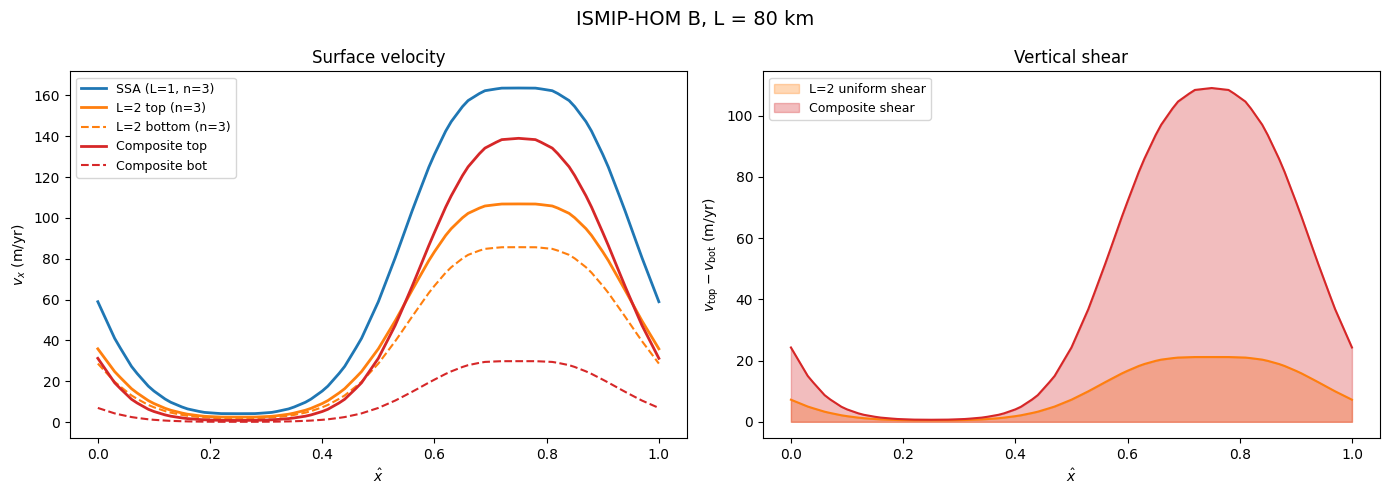

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x_hat, profile_ssa, "C0-", lw=2, label="SSA (L=1, n=3)")
ax1.plot(x_hat, profile_top, "C1-", lw=2, label="L=2 top (n=3)")
ax1.plot(x_hat, profile_bot, "C1--", lw=1.5, label="L=2 bottom (n=3)")
ax1.plot(x_hat, profile_comp_top, "C3-", lw=2, label="Composite top")
ax1.plot(x_hat, profile_comp_bot, "C3--", lw=1.5, label="Composite bot")
ax1.set_xlabel(r"$\hat{x}$")
ax1.set_ylabel(r"$v_x$ (m/yr)")
ax1.set_title("Surface velocity")
ax1.legend(fontsize=9)

ax2.fill_between(
    x_hat, profile_top - profile_bot, alpha=0.3, color="C1",
    label="L=2 uniform shear",
)
ax2.fill_between(
    x_hat, profile_comp_top - profile_comp_bot, alpha=0.3, color="C3",
    label="Composite shear",
)
ax2.plot(x_hat, profile_top - profile_bot, "C1-", lw=1.5)
ax2.plot(x_hat, profile_comp_top - profile_comp_bot, "C3-", lw=1.5)
ax2.set_xlabel(r"$\hat{x}$")
ax2.set_ylabel(r"$v_{\mathrm{top}} - v_{\mathrm{bot}}$ (m/yr)")
ax2.set_title("Vertical shear")
ax2.legend(fontsize=9)

fig.suptitle(f"ISMIP-HOM B, L = {Lx/1e3:.0f} km", fontsize=14)
fig.tight_layout()

## Discussion

The three solutions illustrate the key features of the multilayer model:

**SSA ($L = 1$):** The single-layer model overpredicts the surface velocity because it treats the ice as a plug with no vertical shear.

**Two-layer uniform ($L = 2$, $n = 3$):** Splitting the column into two layers allows vertical shear between them, reducing the surface velocity toward the Stokes solution.

**Composite ($n = 4$ base, $n = 1.8$ top):** The basal layer deforms by dislocation creep (more nonlinear, softer at high stress) while the upper layer deforms by grain boundary sliding (less nonlinear, stiffer at high stress).  This produces a physically motivated velocity profile where shear concentrates near the bed.

The rate factors are calibrated so that all rheologies produce the same strain rate at a reference stress of 0.1 MPa.  This ensures a fair
comparison: the differences in velocity come from the *stress exponents*, not from arbitrarily different fluidities.